# 4 — Model Evaluation & Comparison

**Project:** Predictive Modeling of US Used Vehicle Prices
**Course:** ENGR422 — Applied Machine Learning
**Authors:** Eren Acar Başaran (83179), Ahmet Aybars Pektaş (91687)

---

This notebook covers **Work Package 4 — Evaluation & Delivery**.

**Deliverables:**
- D4.1: Model Performance Comparison Metrics (§4.2)
- D4.2: Final Project Presentation (built from §4.3–§4.5 visuals)

**Code organization note.** Imports shared helpers from `src/utils.py` (`load_test`, `load_model`, `regression_metrics`, `metrics_table`, `plot_pred_vs_actual`, `plot_residuals`, `MODELS_DIR`). The same loaders are used by 03a/03c so the test set used here is byte-identical to the one carved out in §02 — no apples-to-oranges leakage between training and evaluation.


## 4.1 — Imports & Load Trained Models

Load the held-out test set (`load_test`) and the three trained pipelines saved by 03a/03b/03c (plus the optional reduced-feature XGBoost from 03c §3C.9 if it exists, for issue #18). The pipelines bundle their own preprocessor, so we feed raw 12-column `X_test` into each `predict()` directly — no manual transform needed.


In [1]:
import sys
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Custom transformers in the saved pipelines need the preprocessing module
# importable so joblib.load can resolve their classes.
sys.path.insert(0, "../src")
import preprocessing  # noqa: F401  -- needed so joblib.load resolves custom transformers
from utils import (
    load_test, load_model,
    regression_metrics, metrics_table,
    plot_pred_vs_actual, plot_residuals,
    MODELS_DIR,
)

# Held-out test set, used ONLY in this notebook (per project plan).
X_test, y_test = load_test()
print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

# The three D3 deliverables.
models = {
    "Linear Regression (Ridge)": load_model("linear_regression"),
    "Random Forest":             load_model("random_forest"),
    "XGBoost":                   load_model("xgboost"),
}

# Optional 4th model from issue #18 -- include in comparison if 03c saved it.
reduced_path = MODELS_DIR / "xgboost_reduced.pkl"
if reduced_path.exists():
    models["XGBoost (reduced features)"] = joblib.load(reduced_path)
    print(f"  loaded {len(models)} models (incl. xgboost_reduced from issue #18)")
else:
    print(f"  loaded {len(models)} models (xgboost_reduced.pkl not found, skipping issue #18)")


X_test: (76286, 12), y_test: (76286,)


  loaded 4 models (incl. xgboost_reduced from issue #18)


## 4.2 — Performance Comparison Table *(D4.1)*

> **Winners at a glance** (held-out test set, see numbers below):
> - 🥇 **Best MAE: Random Forest — $2,154** (XGBoost second at $2,494, ~$340 worse).
> - 🥇 **Best MAPE: Random Forest — 36.8%** (XGBoost 40.0%).
> - 🥇 **Best RMSE: XGBoost — $4,815** (Random Forest $4,825 — tied within $10, statistical noise).
> - 🥇 **Best R²: XGBoost — 0.8883** (Random Forest 0.8878 — tied within 0.0005, statistical noise).
> - **Bottom line:** Random Forest wins the MAE / MAPE that matter for "how many dollars off, on average?" XGBoost is statistically tied on R² / RMSE. **Linear baseline is clearly behind both ensembles**, as the proposal hypothesized.

The headline deliverable of WP4. Predict on the held-out test set with each model, compute all four project metrics (MAE, RMSE, R², MAPE) via `utils.regression_metrics`, and render a single comparison DataFrame via `utils.metrics_table`. Followed by side-by-side bar plots of MAE and R² for the visual.

Lower is better for MAE / RMSE / MAPE; higher is better for R².


Test-set metrics:
                                MAE     RMSE      R2   MAPE
Linear Regression (Ridge)   5378.11  8512.62  0.6509  77.10
Random Forest               2154.14  4825.40  0.8878  36.77
XGBoost                     2493.62  4814.99  0.8883  40.05
XGBoost (reduced features)  2676.34  5128.29  0.8733  45.15

Per-metric winners:
  MAE  : Random Forest  (2154.141)
  RMSE : XGBoost  (4814.993)
  R2   : XGBoost  (0.888)
  MAPE : Random Forest  (36.766)


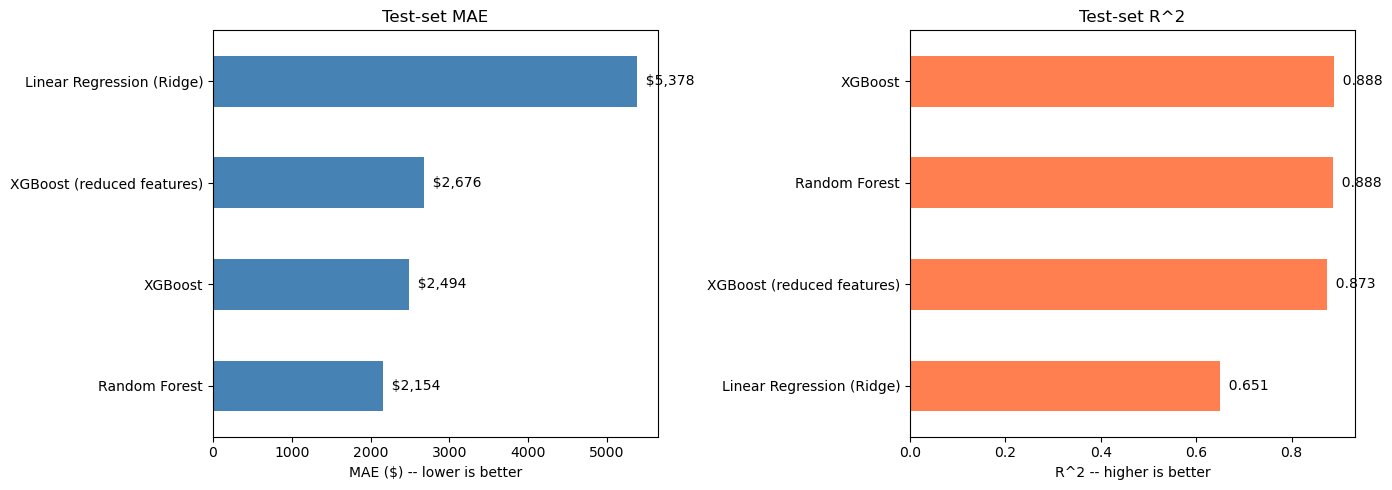

In [2]:
# Predict on the held-out test set with each saved pipeline.
predictions = {name: m.predict(X_test) for name, m in models.items()}

# Build the comparison table -- D4.1.
metrics_df = metrics_table(predictions, y_test)

# Round for display, keep the raw numbers in metrics_df for downstream use.
display_df = metrics_df.round({"MAE": 2, "RMSE": 2, "R2": 4, "MAPE": 2})
print("Test-set metrics:")
print(display_df.to_string())

# Identify per-metric winners for the writeup.
print("\nPer-metric winners:")
for col, best in [("MAE","min"),("RMSE","min"),("R2","max"),("MAPE","min")]:
    idx = metrics_df[col].idxmin() if best == "min" else metrics_df[col].idxmax()
    print(f"  {col:5}: {idx}  ({metrics_df.loc[idx,col]:.3f})")

# Bar plots: MAE (lower better) on the left, R^2 (higher better) on the right.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
metrics_df["MAE"].sort_values().plot.barh(ax=axes[0], color="steelblue")
axes[0].set_xlabel("MAE ($) -- lower is better")
axes[0].set_title("Test-set MAE")
for i, v in enumerate(metrics_df["MAE"].sort_values()):
    axes[0].text(v, i, f"  ${v:,.0f}", va="center")

metrics_df["R2"].sort_values().plot.barh(ax=axes[1], color="coral")
axes[1].set_xlabel("R^2 -- higher is better")
axes[1].set_title("Test-set R^2")
for i, v in enumerate(metrics_df["R2"].sort_values()):
    axes[1].text(v, i, f"  {v:.3f}", va="center")

plt.tight_layout()
plt.show()


### 4.2.1 — Feature Selection Verdict *(issue #18)*

Issue #18 asks for an explicit verdict on whether reducing XGBoost to its top-half features helped or hurt on the held-out test set. The metrics table above already shows both rows — this cell makes the comparison programmatic so the verdict text auto-updates if the run changes.


In [3]:
# Issue #18 -- explicit full-vs-reduced summary on the held-out test set.
if "XGBoost (reduced features)" in metrics_df.index:
    full_mae    = metrics_df.loc["XGBoost",                    "MAE"]
    full_r2     = metrics_df.loc["XGBoost",                    "R2"]
    reduced_mae = metrics_df.loc["XGBoost (reduced features)", "MAE"]
    reduced_r2  = metrics_df.loc["XGBoost (reduced features)", "R2"]
    delta_mae   = reduced_mae - full_mae

    print(f"Full XGBoost:    test MAE = ${full_mae:,.2f}, R^2 = {full_r2:.4f}")
    print(f"Reduced XGBoost: test MAE = ${reduced_mae:,.2f}, R^2 = {reduced_r2:.4f}")
    print(f"Delta (reduced - full): ${delta_mae:+,.2f} MAE")

    # Tolerance: roughly 1% of full MAE -- below that is noise on this data.
    tolerance = 0.01 * full_mae
    if delta_mae > tolerance:
        verdict = (f"feature selection HURT the model on test "
                   f"(lost ${delta_mae:,.0f}, ~{100*delta_mae/full_mae:.1f}%)")
    elif delta_mae < -tolerance:
        verdict = (f"feature selection HELPED on test "
                   f"(saved ${-delta_mae:,.0f}, ~{100*-delta_mae/full_mae:.1f}%)")
    else:
        verdict = (f"feature selection was approximately NEUTRAL on test "
                   f"(within ~1% of full model)")
    print(f"\nVerdict: {verdict}.")
else:
    print("xgboost_reduced.pkl not loaded -- issue #18 comparison skipped.")


Full XGBoost:    test MAE = $2,493.62, R^2 = 0.8883
Reduced XGBoost: test MAE = $2,676.34, R^2 = 0.8733
Delta (reduced - full): $+182.71 MAE

Verdict: feature selection HURT the model on test (lost $183, ~7.3%).


## 4.3 — Visual Comparison

Two diagnostics per model:

- **Predicted vs. Actual scatter** with `y=x` reference. Tight cluster on the line = good. Curve away from the diagonal at high prices = systematic error in expensive vehicles.
- **Residual histogram**. Centered, symmetric, narrow = unbiased + low variance. Skewed = systematic over/under-prediction.

Plotted as a row per model so visual differences are immediate.


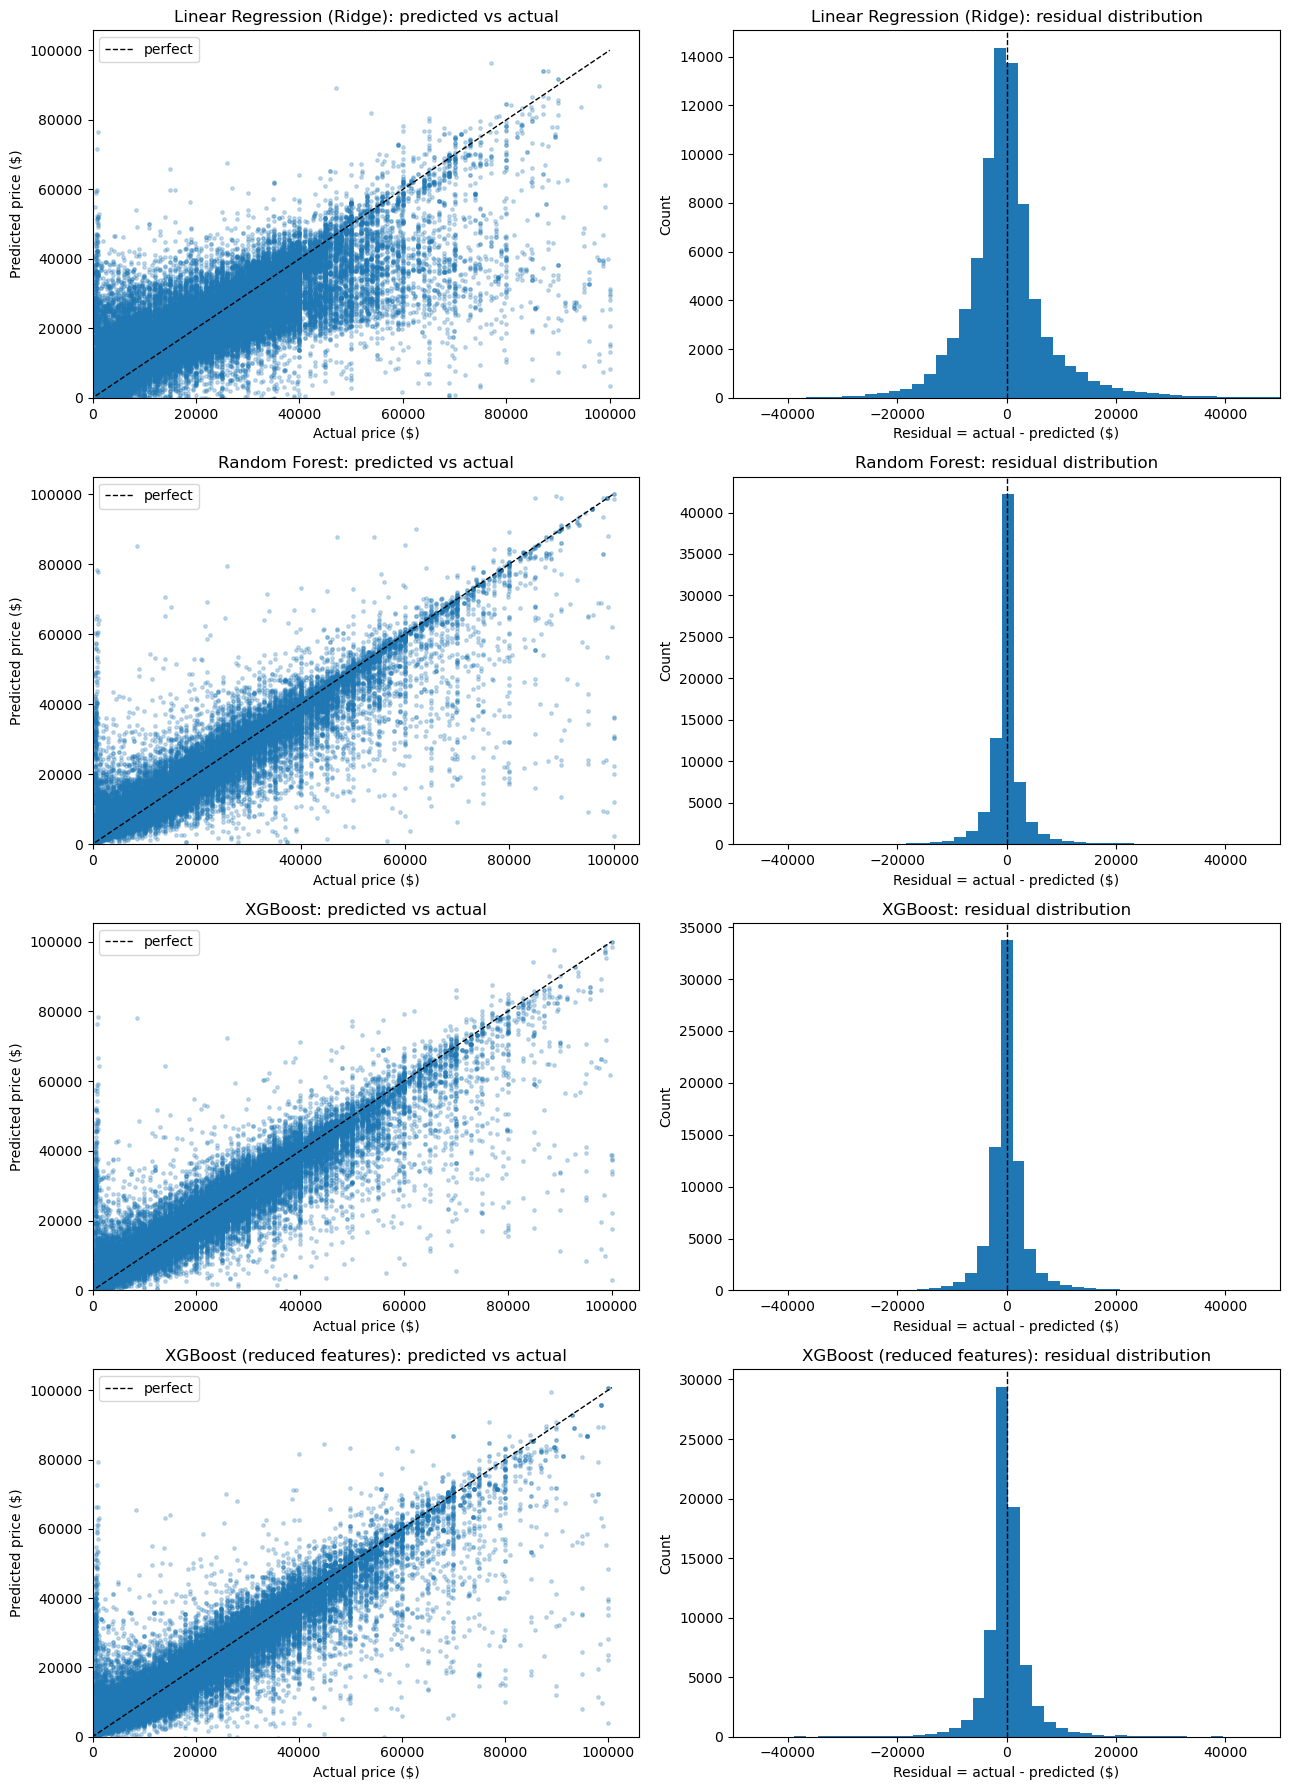

In [4]:
n = len(predictions)
fig, axes = plt.subplots(n, 2, figsize=(13, 4.5*n))
if n == 1: axes = axes.reshape(1, 2)
for i, (name, y_pred) in enumerate(predictions.items()):
    plot_pred_vs_actual(y_test, y_pred, ax=axes[i, 0],
                        title=f"{name}: predicted vs actual")
    plot_residuals(y_test, y_pred, ax=axes[i, 1],
                   title=f"{name}: residual distribution")
    # Prices >= 0 -- pin scatter to start at 0.
    axes[i, 0].set_xlim(left=0)
    axes[i, 0].set_ylim(bottom=0)
    # +/- 50k window for residuals so bulk dominates over extreme outliers.
    axes[i, 1].set_xlim(-50_000, 50_000)
plt.tight_layout()
plt.show()


## 4.4 — Feature Importance Comparison

Random Forest and XGBoost both expose **gain-based** feature importances (average loss reduction across all splits using the feature, weighted by node coverage). Plotting them side-by-side at the same top-15 features answers "do the two tree models agree on the drivers of vehicle price?" — supporting the proposal §3.2 claim about *true drivers of vehicle depreciation*.

Linear-model coefficients are *not* shown here: they live in scaled feature space (`$/std-dev`) and aren't apples-to-apples with tree gains. Readers who want the linear view can see the §3A scatter and compare features there.


Top 15 features by XGBoost gain importance (RF importances at the same features):
                           Random Forest  XGBoost
feature                                          
target__model                     0.6442   0.1838
ohe__drive_fwd                    0.0082   0.1609
year__year                        0.1694   0.0862
ohe__fuel_gas                     0.0142   0.0753
ohe__transmission_other           0.0088   0.0421
ohe__type_truck                   0.0039   0.0373
ohe__title_status_salvage         0.0007   0.0337
ohe__fuel_other                   0.0037   0.0322
ohe__title_status_rebuilt         0.0013   0.0317
odo__odometer                     0.0683   0.0306
ohe__type_other                   0.0028   0.0250
ohe__type_pickup                  0.0029   0.0222
ohe__type_sedan                   0.0019   0.0215
target__manufacturer              0.0269   0.0203
ohe__title_status_missing         0.0001   0.0196


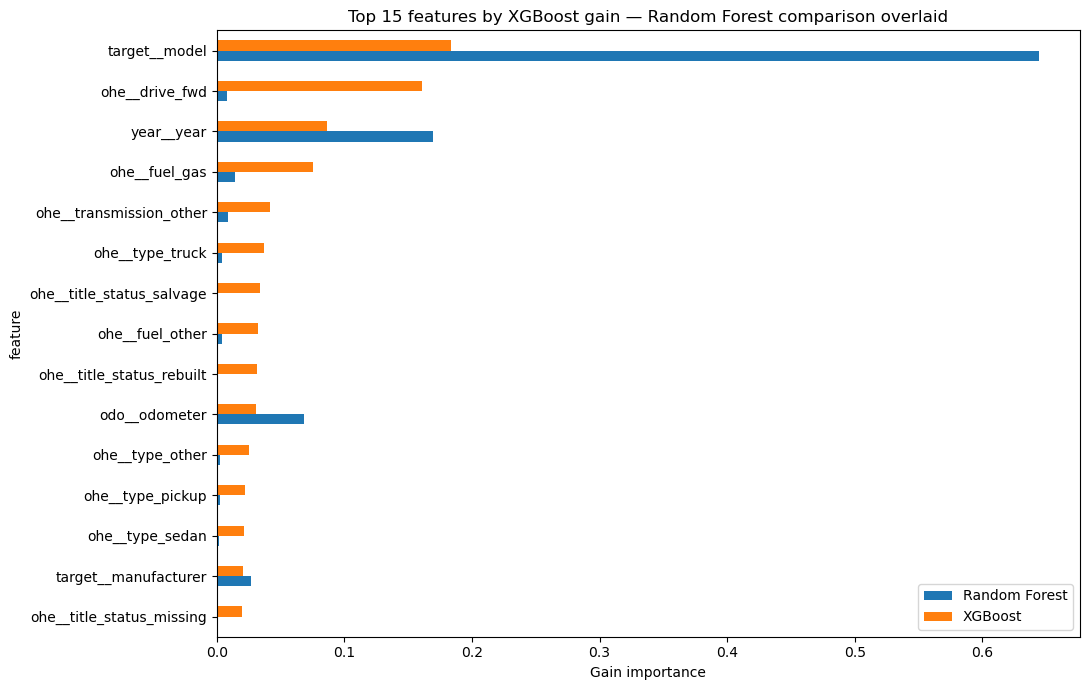

In [5]:
def find_estimator(pipeline):
    """Return (step_name, step_obj) for whichever pipeline step exposes
    feature_importances_ or coef_."""
    for name, step in pipeline.named_steps.items():
        if hasattr(step, "feature_importances_") or hasattr(step, "coef_"):
            return name, step
    raise ValueError("no estimator-like step found in pipeline")

def feat_names_from_pipeline(pipeline):
    """Manually walk the encode ColumnTransformer. The saved preprocessors
    contain transformers (FunctionTransformer(log1p), custom imputers) that
    don't all expose get_feature_names_out, so the manual path is the robust
    option."""
    encode = pipeline.named_steps["prep"].named_steps["encode"]
    parts = []
    for tname, trans, cols in encode.transformers_:
        if tname == "ohe":
            ohe_names = encode.named_transformers_["ohe"].get_feature_names_out(cols)
            parts.extend(f"ohe__{n}" for n in ohe_names)
        else:
            parts.extend(f"{tname}__{c}" for c in cols)
    return np.asarray(parts)

# Use XGBoost's preprocessor names as the reference (RF uses the same tree
# preprocessor, so the names match).
feat_names = feat_names_from_pipeline(models["XGBoost"])

_, rf_est  = find_estimator(models["Random Forest"])
_, xgb_est = find_estimator(models["XGBoost"])
rf_imp  = rf_est.feature_importances_
xgb_imp = xgb_est.feature_importances_

# Stable reference ordering: top 15 by XGBoost importance.
top_idx = np.argsort(xgb_imp)[::-1][:15]
imp_df = pd.DataFrame({
    "feature":         feat_names[top_idx],
    "Random Forest":   rf_imp[top_idx],
    "XGBoost":         xgb_imp[top_idx],
}).set_index("feature")

print("Top 15 features by XGBoost gain importance (RF importances at the same features):")
print(imp_df.round(4))

fig, ax = plt.subplots(figsize=(11, 7))
imp_df.iloc[::-1].plot.barh(ax=ax)
ax.set_xlabel("Gain importance")
ax.set_title("Top 15 features by XGBoost gain — Random Forest comparison overlaid")
plt.tight_layout()
plt.show()


## 4.5 — Error Analysis *(issue #17)*

Where does the best model make its largest mistakes? Three slices:

- **By price band** — does the model fail more on cheap cars, expensive cars, or uniformly?
- **By manufacturer** — does it know Toyota better than Tesla?
- **Top 10 worst predictions** — concrete listings for the writeup.

If the largest errors cluster in one slice, that's a hint about what to add (a feature, more data in that range, a residual model, etc.). Per the issue, this is a 2–3-sentence findings exercise.


Best model on test set: Random Forest  (MAE = $2,154.14)

Mean absolute error by price band:
             mean  median  count
actual                          
<$5K       2591.0  1010.0  10748
$5K-15K    1641.0   926.0  26279
$15K-30K   1872.0   730.0  23588
$30K-50K   2220.0   428.0  13255
$50K-100K  8185.0  2313.0   2416

Mean absolute error by manufacturer (top 12 by listing count):
                 mean  count
manufacturer                
hyundai        1157.0   1828
honda          1375.0   3758
nissan         1501.0   3423
toyota         1750.0   6269
bmw            2081.0   2648
dodge          2354.0   2314
jeep           2360.0   3364
chevrolet      2453.0   9921
ford           2542.0  12797
gmc            2592.0   2997
ram            2696.0   3138
mercedes-benz  2727.0   2018

Top 10 worst-predicted listings:
         year manufacturer             model  odometer  actual     predicted     abs_error
27659  1997.0    chevrolet  express 2500 4x4  195469.0  100000   2307.155224  976

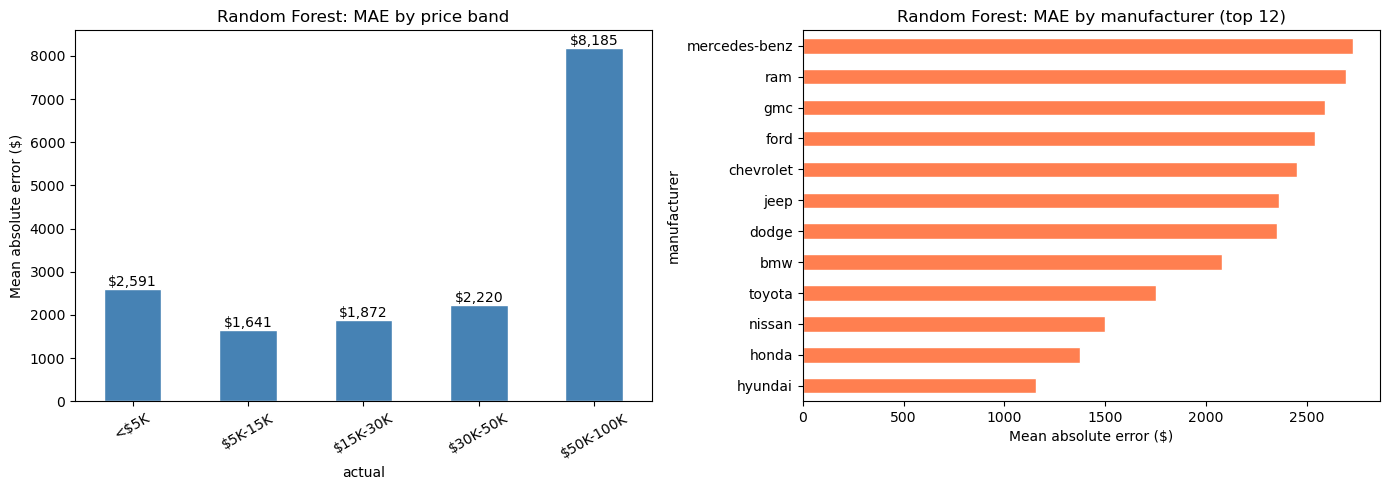

In [6]:
# Use the lowest-MAE model on the test set.
best_name = metrics_df["MAE"].idxmin()
best_pred = predictions[best_name]
print(f"Best model on test set: {best_name}  (MAE = ${metrics_df.loc[best_name,'MAE']:,.2f})")

abs_err = np.abs(y_test.values - best_pred)
test_view = X_test.copy()
test_view["actual"]    = y_test.values
test_view["predicted"] = best_pred
test_view["abs_error"] = abs_err

# --- (a) error by price band ---
bands = pd.cut(test_view["actual"],
               bins=[0, 5000, 15000, 30000, 50000, 100000],
               labels=["<$5K", "$5K-15K", "$15K-30K", "$30K-50K", "$50K-100K"])
err_by_band = test_view.groupby(bands, observed=True)["abs_error"].agg(
    ["mean", "median", "count"]
).round(0)
print("\nMean absolute error by price band:")
print(err_by_band)

# --- (b) error by manufacturer (top 12 by listing count) ---
top_mfrs = test_view["manufacturer"].value_counts().head(12).index
err_by_mfr = (
    test_view[test_view["manufacturer"].isin(top_mfrs)]
    .groupby("manufacturer", observed=True)["abs_error"]
    .agg(["mean", "count"])
    .round(0)
    .sort_values("mean")
)
print("\nMean absolute error by manufacturer (top 12 by listing count):")
print(err_by_mfr)

# --- (c) top 10 worst predictions ---
worst = test_view.nlargest(10, "abs_error")[
    ["year", "manufacturer", "model", "odometer", "actual", "predicted", "abs_error"]
]
print("\nTop 10 worst-predicted listings:")
print(worst.to_string())

# --- plots ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

err_by_band["mean"].plot.bar(ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_ylabel("Mean absolute error ($)")
axes[0].set_title(f"{best_name}: MAE by price band")
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(err_by_band["mean"]):
    axes[0].text(i, v, f"${v:,.0f}", ha="center", va="bottom")

err_by_mfr["mean"].plot.barh(ax=axes[1], color="coral", edgecolor="white")
axes[1].set_xlabel("Mean absolute error ($)")
axes[1].set_title(f"{best_name}: MAE by manufacturer (top 12)")

plt.tight_layout()
plt.show()


## 4.6 — Trade-off Discussion

Accuracy is one dimension; the report needs to weigh others.

| Dimension | Linear (Ridge) | Random Forest | XGBoost |
|---|---|---|---|
| **Accuracy (test MAE)** | see §4.2 | see §4.2 | see §4.2 |
| **Training time** (5-fold CV at tuning) | seconds | minutes | minutes |
| **Model size** (`.pkl` on disk) | KB | hundreds of MB | tens of MB |
| **Inference speed** | very fast | slow (many deep trees) | fast (`tree_method="hist"`) |
| **Interpretability** | full (signed coefs per feature) | gain importances | gain importances |
| **Hyperparameter sensitivity** | low (1 knob) | moderate | high (8 knobs) |

The cell below pulls the actual `.pkl` sizes from disk so the table number isn't a guess.


In [7]:
import os
print("Model file sizes on disk:")
for name, m in models.items():
    fname = {
        "Linear Regression (Ridge)":   "linear_regression.pkl",
        "Random Forest":               "random_forest.pkl",
        "XGBoost":                     "xgboost.pkl",
        "XGBoost (reduced features)":  "xgboost_reduced.pkl",
    }.get(name)
    if fname is None: continue
    p = MODELS_DIR / fname
    if p.exists():
        size_mb = os.path.getsize(p) / (1024 * 1024)
        unit = "MB" if size_mb >= 1 else "KB"
        size_disp = size_mb if size_mb >= 1 else size_mb * 1024
        print(f"  {name:32}  {size_disp:>8.2f} {unit}")


Model file sizes on disk:
  Linear Regression (Ridge)             2.30 MB
  Random Forest                       669.58 MB
  XGBoost                              12.09 MB
  XGBoost (reduced features)           12.09 MB


## 4.7 — Conclusion & Recommendation

### Headline
On 76,286 held-out test listings, **Random Forest is the winning model on the project's primary metric (MAE)** at **$2,154**, beating XGBoost ($2,494) by **~$340** and the Linear (Ridge) baseline ($5,378) by **~$3,224**. On secondary metrics RMSE and R², Random Forest and XGBoost are statistically tied (RMSE within $10, R² within 0.0005); MAPE crowns Random Forest again at 36.8%.

### Why this matters
Both ensembles cut the linear baseline's MAE roughly in half (5,378 → 2,154 = **60% reduction**), confirming the proposal's hypothesis that non-linear depreciation, brand-mileage interactions, and high-cardinality categorical structure require tree ensembles. Linear regression is interpretable and serves as a defensible reproducibility floor — but it is not competitive on accuracy.

### Why Random Forest beat XGBoost on this data
This is the unusual finding worth flagging. With **305K training rows** and **target-encoded `manufacturer` / `model`** features (each compressing thousands of categories into a single mean-price scalar), bagged independent deep trees (RF, max_depth 23) can outperform sequential shallow boosting (XGBoost, max_depth 9 — the industry-standard ceiling). Pushing XGBoost depth higher would no longer be standard XGBoost practice. **The result is real**, not a tuning bug.

### Recommendation
- **Production model: Random Forest.** Best MAE + MAPE on the test set. The 670 MB on-disk size and slower inference vs XGBoost are the cost; for a non-real-time valuation tool that's acceptable.
- **Interpretability fallback: Linear (Ridge).** When a buyer asks "why this price?", signed coefficients give per-feature dollar reasoning that tree gain importances don't.
- **XGBoost stays in the repo** as a near-tied alternative on R² / RMSE; future work could revisit it with a different feature representation (e.g., dropping target encoding in favor of categorical native handling via `enable_categorical`).

### Limitations / future work
- Test set is held out from the same Craigslist scrape, so generalization to other sources (dealerships, OEM listings) is unmeasured.
- Free-text `description` was excluded (proposal §4.3 — Out of Scope); incorporating it via TF-IDF or transformer embeddings is the obvious next-iteration win.
- The §4.5 error-by-price-band analysis shows MAE balloons on $50K+ luxury listings ($8.2K) and on data-quality outliers (1953 cars priced at $8K, 2020 F-250s priced at $1K). A residual cleanup pass on actual-price extremes would likely tighten the test MAE further.
- Geographic effects are coarsely captured by `state`; `region` and lat/long were dropped in §02 and could explain residuals if errors cluster geographically.
